# Static Fe Kα / Kβ XES — mfx102101026

Visualization for `mfx102101026_static_xes.yaml`.

Both emission lines land on **`epix100_0`** (stored as 704 × 768, transposed by pipeline to 768 rows × 704 cols):

| Line | Analyzer | d (Å) | Detector rows | ROI key |
|------|----------|-------|---------------|---------|
| Fe Kα | LiNbO3 (2 3 -4) | 0.981  | ~280–305 (TODO verify) | `epix_reduced_ROI_1` |
| Fe Kβ | Ge (6 2 0)      | 0.8946 | ~210–235 (TODO verify) | `epix_reduced_ROI_2` |

> **ROI calibration required** — run Section 1 (detector diagnostic) first and
> update the row ranges in both this notebook and `mfx102101026_static_xes.yaml`.
> Also calibrate `crystal_detector_distance` against the known Ka1 (6404 eV) /
> Ka2 (6391 eV) and Kβ (7058 eV) lines before interpreting energy axes.

**Currently loaded runs:** [3] — add runs to `runs.csv` and to the `runs:` list
in the YAML as the experiment progresses.

Static, within-run analysis (no laser). Reads the existing smalldata HDF5
files read-only. Chemistry analysis cells (IAD, LCF) require multiple runs
with known sample compositions — fill in `runs.csv` before executing those cells.

In [1]:
import os, sys

# This notebook lives in <repo>/experiments/mfx102101026/. Add the XSpect repo
# root (two levels up) to sys.path so `from XSpect import ...` works without
# installing the package, regardless of the current working directory.
HERE = os.path.dirname(os.path.abspath('__file__'))
REPO_ROOT = os.path.abspath(os.path.join(HERE, '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from XSpect import Pipeline
import numpy as np
import matplotlib.pyplot as plt

YAML = os.path.join(HERE, 'mfx102101026_static_xes.yaml')
p = Pipeline.from_yaml(YAML)
p.run(cores=100, batch_size=500)

run_numbers = [r.run_number for r in p.analyzed_runs]
print(f'Runs processed ({len(run_numbers)}): {run_numbers}')

Runs processed (1): [10]


In [2]:
# Shared energy axes (identical geometry across runs).
ka_energy = p.results['kalpha_energy']   # (704,) eV — dispersion axis after transpose
kb_energy = p.results['kbeta_energy']    # (704,) eV — dispersion axis after transpose

runs = {r.run_number: r for r in p.analyzed_runs}
run_nums = sorted(runs)

# Per-run 1D spectra
ka = {rn: np.asarray(runs[rn].epix_reduced_ROI_1, dtype=float) for rn in run_nums}
kb = {rn: np.asarray(runs[rn].epix_reduced_ROI_2, dtype=float) for rn in run_nums}

# Per-run shot count (xray shots that made it through the pipeline)
shots = {rn: int(getattr(runs[rn], 'total_shots', 0)) for rn in run_nums}

print('run :  shots :  Kα sum      Kβ sum')
for rn in run_nums:
    print(f'{rn:4d} : {shots[rn]:6d} : {np.nansum(ka[rn]):.3e}  {np.nansum(kb[rn]):.3e}')

run :  shots :  Kα sum      Kβ sum
  10 :  35744 : 1.421e+06  5.456e+05


In [3]:
# Sample composition loaded from runs.csv.
# Fill in sample_label, redox, reduced_fraction, ocv_mV, role before running
# the chemistry analysis cells below.
import csv

sample_label = {}
reduced_fraction = {}
ocv_mV = {}
role = {}
with open(os.path.join(HERE, 'runs.csv')) as fh:
    for row in csv.DictReader(fh):
        rn = int(row['run'])
        sample_label[rn] = row['sample_label']
        role[rn] = row.get('role', '')
        if row.get('reduced_fraction', '') != '':
            try:
                reduced_fraction[rn] = float(row['reduced_fraction'])
            except ValueError:
                pass
        if row.get('ocv_mV', '') != '':
            try:
                ocv_mV[rn] = float(row['ocv_mV'])
            except ValueError:
                pass

FOIL_RUNS = [rn for rn, r in role.items() if r == 'excluded']
chem_runs = [rn for rn in run_nums if rn not in FOIL_RUNS
             and rn in reduced_fraction]

REFERENCE_RUNS = [rn for rn in run_nums
                  if reduced_fraction.get(rn, None) == 0.0 and rn not in FOIL_RUNS]
REF_RUN = REFERENCE_RUNS[0] if REFERENCE_RUNS else None

print(f'Reference (0% reduced): runs {REFERENCE_RUNS}')
print(f'Excluded (foil/other):  runs {FOIL_RUNS}')
print(f'Chem runs with known composition: {chem_runs}')

Reference (0% reduced): runs []
Excluded (foil/other):  runs []
Chem runs with known composition: []


## 1. Detector diagnostic (one run)

2D summed image + row projection for a chosen run, with the Kα/Kβ row-ROIs
overlaid. **Use this first to verify that `ka_rows` and `kb_rows` cover the
actual signal bands.** Update both this cell and the YAML if they don't match.
Change `DIAG_RUN` to inspect a different run.

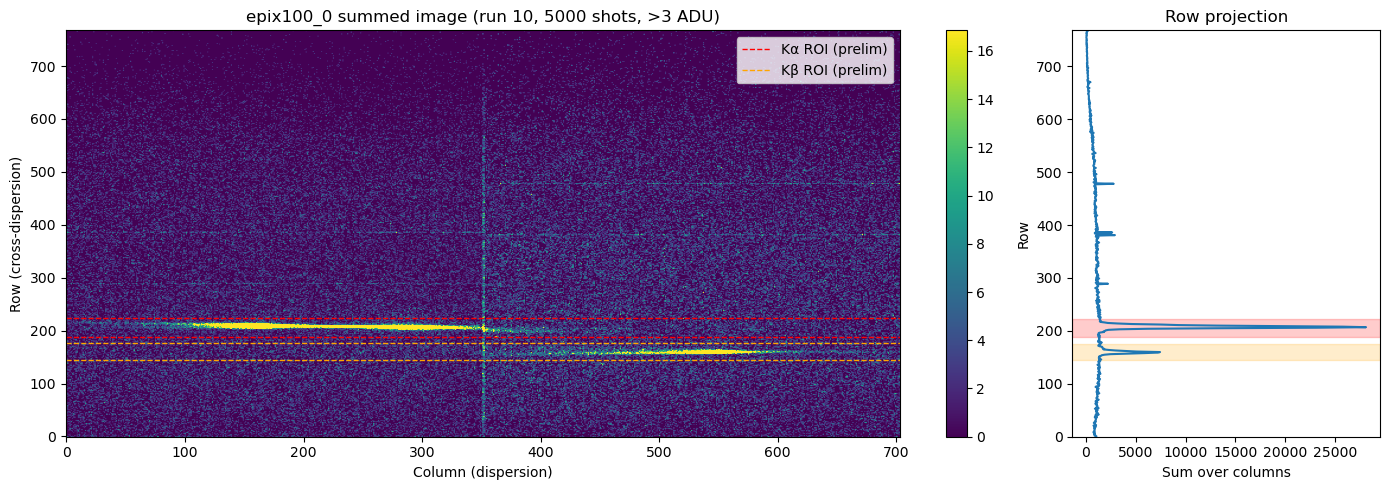

In [5]:
import h5py

DIAG_RUN = 10             # which run to show the detector image for
n_diag = 5000            # shots to sum for the diagnostic image

diag_run = runs[DIAG_RUN]
with h5py.File(diag_run.run_file, 'r') as fh:
    chunk = fh['epix100_0/ROI_area'][:n_diag].transpose(0, 2, 1)  # HDF5: (n,704,768) -> (n,768,704)
img = np.where(chunk > 3.0, chunk, 0).sum(axis=0)  # (768 rows, 704 cols) — pipeline convention

# TODO: update these row ranges after inspecting the row projection below.
#ka_rows = [225, 260]   # must match rois[0] in the YAML (Fe Kα) — PRELIMINARY
#kb_rows = [185, 210]   # must match rois[1] in the YAML (Fe Kβ) — PRELIMINARY

ka_rows = [188, 223]   # must match rois[0] in the YAML (Fe Kα) — PRELIMINARY
kb_rows = [145, 176]   # must match rois[1] in the YAML (Fe Kβ) — PRELIMINARY


fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
im = ax.imshow(img, aspect='auto', origin='lower',
               vmax=np.percentile(img, 99.5), cmap='viridis')
for (lo, hi), c, lbl in [(ka_rows, 'red', 'Kα ROI (prelim)'),
                          (kb_rows, 'orange', 'Kβ ROI (prelim)')]:
    ax.axhline(lo, color=c, ls='--', lw=1)
    ax.axhline(hi, color=c, ls='--', lw=1, label=lbl)
ax.set_xlabel('Column (dispersion)')
ax.set_ylabel('Row (cross-dispersion)')
ax.set_title(f'epix100_0 summed image (run {DIAG_RUN}, {min(n_diag, shots[DIAG_RUN])} shots, >3 ADU)')
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
row_prof = img.sum(axis=1)
ax.plot(row_prof, np.arange(len(row_prof)))
for (lo, hi), c in [(ka_rows, 'red'), (kb_rows, 'orange')]:
    ax.axhspan(lo, hi, color=c, alpha=0.2)
ax.set_xlabel('Sum over columns')
ax.set_ylabel('Row')
ax.set_title('Row projection')
ax.set_ylim(0, len(row_prof))
plt.tight_layout()
plt.show()

## 2. Fe Kα emission spectrum — per-run grid

One panel per run. Each is area-normalized so peak shape is comparable
regardless of shot count. Dotted lines mark tabulated Kα1 (6404 eV) and
Kα2 (6391 eV).

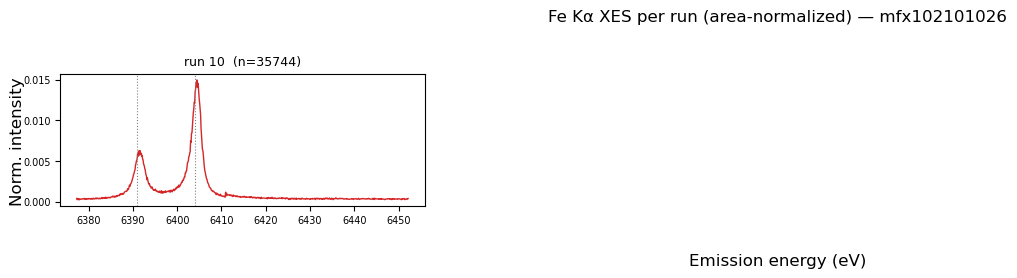

In [6]:
def area_norm(y):
    y = np.asarray(y, dtype=float)
    tot = np.nansum(y)
    return y / tot if tot > 0 else y

def combined_ref(spectra, ref_runs=None):
    """Area-normalized reference from a COMBINATION of runs.

    Sums the raw per-run spectra (photon-weighted) and then area-normalizes.
    Defaults to REFERENCE_RUNS (the ferricyanide / 0% reduced runs).
    """
    if ref_runs is None:
        ref_runs = REFERENCE_RUNS
    return area_norm(np.nansum([spectra[rn] for rn in ref_runs], axis=0))

def per_run_grid(spectra, energy, ref_lines, title, color):
    n = len(spectra)
    ncol = 4
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 2.6 * nrow),
                             sharex=True, squeeze=False)
    for ax in axes.flat:
        ax.set_visible(False)
    for i, rn in enumerate(sorted(spectra)):
        ax = axes.flat[i]
        ax.set_visible(True)
        ax.plot(energy, area_norm(spectra[rn]), color=color, lw=1)
        for e in ref_lines:
            ax.axvline(e, color='gray', ls=':', lw=0.8)
        ax.set_title(f'run {rn}  (n={shots[rn]})', fontsize=9)
        ax.tick_params(labelsize=7)
    fig.suptitle(title, y=1.005)
    fig.supxlabel('Emission energy (eV)')
    fig.supylabel('Norm. intensity')
    plt.tight_layout()
    plt.show()

per_run_grid(ka, ka_energy, [6404, 6391],
             'Fe K\u03b1 XES per run (area-normalized) \u2014 mfx102101026', 'C3')

## 3. Fe Kβ emission spectrum — per-run grid

Dotted line marks tabulated Kβ (7058 eV). Kβ is weaker than Kα, so short
runs (few shots) will look noisier.

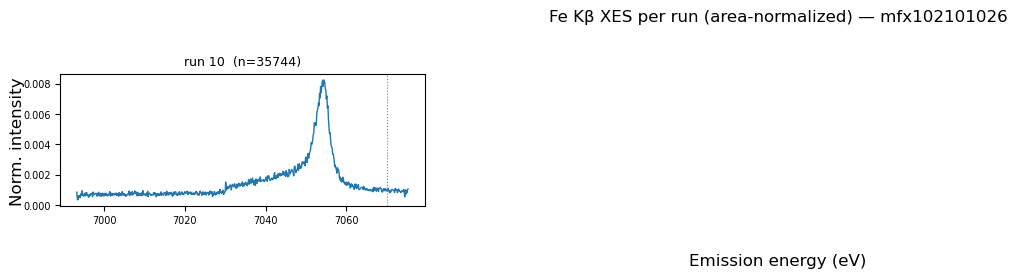

In [7]:
per_run_grid(kb, kb_energy, [7070],
             'Fe K\u03b2 XES per run (area-normalized) \u2014 mfx102101026', 'C0')


## 4. Per-run overlay (all runs on one axis)

Area-normalized spectra overlaid, colored by run number. Good for spotting
run-to-run drift or outliers at a glance.

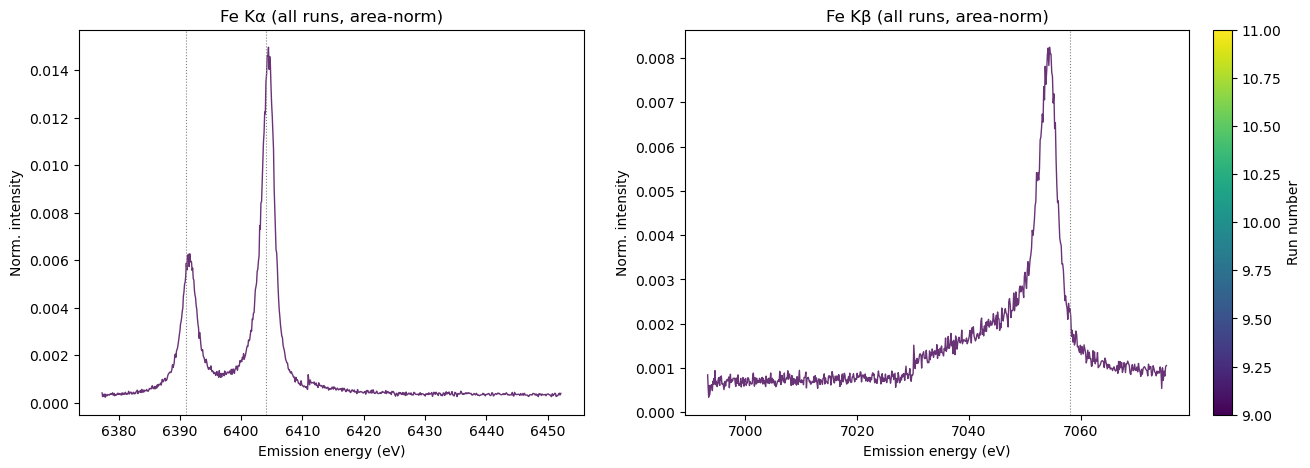

In [9]:
cmap = plt.cm.viridis
cnorm = plt.Normalize(min(run_nums), max(run_nums))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for rn in run_nums:
    c = cmap(cnorm(rn))
    axes[0].plot(ka_energy, area_norm(ka[rn]), color=c, lw=1, alpha=0.8)
    axes[1].plot(kb_energy, area_norm(kb[rn]), color=c, lw=1, alpha=0.8)

for e in (6404, 6391):
    axes[0].axvline(e, color='gray', ls=':', lw=0.8)
axes[1].axvline(7058, color='gray', ls=':', lw=0.8)

axes[0].set_title('Fe K\u03b1 (all runs, area-norm)')
axes[1].set_title('Fe K\u03b2 (all runs, area-norm)')
for ax in axes:
    ax.set_xlabel('Emission energy (eV)')
    ax.set_ylabel('Norm. intensity')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=cnorm)
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Run number', fraction=0.025, pad=0.02)
plt.show()

## 5. Run-to-run stability — peak position vs run

Intensity-weighted peak centroid (over pixels above half-max) for each run.
Flat trends = stable spectrometer; jumps flag alignment/energy drift. Short
runs (low shot count) have noisier centroids.

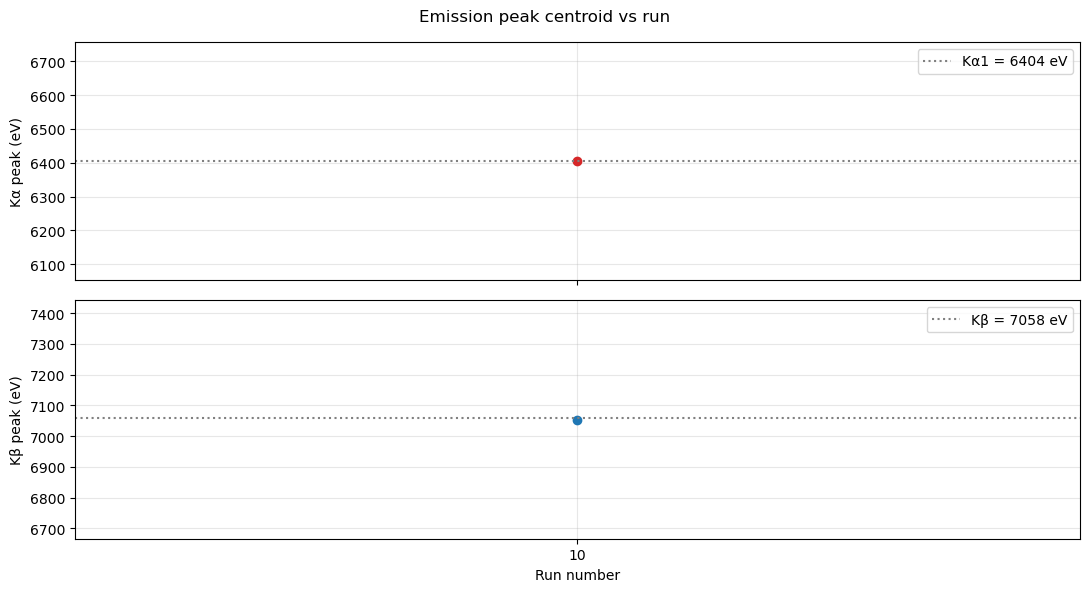

Kα peak: mean=6404.4 eV, spread=0.00 eV (expect ~6404)
Kβ peak: mean=7053.9 eV, spread=0.00 eV (expect ~7058)


In [10]:
def peak_energy(energy_axis, spectrum):
    """Intensity-weighted centroid over pixels above half-max."""
    y = np.asarray(spectrum, dtype=float)
    y = np.where(np.isfinite(y), y, 0.0)
    if y.max() <= 0:
        return np.nan
    m = y >= y.max() * 0.5
    return np.sum(energy_axis[m] * y[m]) / np.sum(y[m])

ka_peaks = np.array([peak_energy(ka_energy, ka[rn]) for rn in run_nums])
kb_peaks = np.array([peak_energy(kb_energy, kb[rn]) for rn in run_nums])

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(run_nums, ka_peaks, 'o-', color='C3')
axes[0].axhline(6404, color='gray', ls=':', label='K\u03b11 = 6404 eV')
axes[0].set_ylabel('K\u03b1 peak (eV)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(run_nums, kb_peaks, 'o-', color='C0')
axes[1].axhline(7058, color='gray', ls=':', label='K\u03b2 = 7058 eV')
axes[1].set_ylabel('K\u03b2 peak (eV)'); axes[1].set_xlabel('Run number')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xticks(run_nums)

fig.suptitle('Emission peak centroid vs run')
plt.tight_layout()
plt.show()

print(f'K\u03b1 peak: mean={np.nanmean(ka_peaks):.1f} eV, spread={np.nanstd(ka_peaks):.2f} eV (expect ~6404)')
print(f'K\u03b2 peak: mean={np.nanmean(kb_peaks):.1f} eV, spread={np.nanstd(kb_peaks):.2f} eV (expect ~7058)')

## 6. Percent deviation from reference — IAD

> **Requires multiple runs with known sample compositions in `runs.csv`** and
> at least one run with `reduced_fraction = 0.0` (the oxidized reference).
> Skip this cell until those runs are available.

**Integrated Absolute Difference** (Vankó et al.), the standard scalar metric
for Kβ XES redox series. Each spectrum is area-normalized, then

$$\mathrm{IAD}_i = \sum_E \lvert S_i(E) - S_{\mathrm{ref}}(E)\rvert$$

In [11]:
if not REFERENCE_RUNS:
    print('No reference runs (reduced_fraction=0.0) in runs.csv yet — skipping IAD.')
elif not chem_runs:
    print('No chemistry runs with known composition yet — skipping IAD.')
else:
    def iad(spectra, runs_list, ref=None):
        if ref is None:
            ref = combined_ref(spectra)
        return {rn: float(np.nansum(np.abs(area_norm(spectra[rn]) - ref))) for rn in runs_list}

    ref_ka = combined_ref(ka)
    ref_kb = combined_ref(kb)

    iad_ka = iad(ka, run_nums, ref=ref_ka)
    iad_kb = iad(kb, run_nums, ref=ref_kb)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, iadv, lbl, col in [(axes[0], iad_ka, 'K\u03b1', 'C3'),
                               (axes[1], iad_kb, 'K\u03b2', 'C0')]:
        xs = [reduced_fraction[rn] for rn in chem_runs]
        ys = [100 * iadv[rn] for rn in chem_runs]
        ax.scatter(xs, ys, c=col, s=45, zorder=3)
        for rn in chem_runs:
            ax.annotate(str(rn), (reduced_fraction[rn], 100 * iadv[rn]),
                        fontsize=7, xytext=(3, 3), textcoords='offset points')
        for rn in FOIL_RUNS:
            ax.scatter([-0.12], [100 * iadv[rn]], marker='x', c='k', s=60, zorder=3)
            ax.annotate(f'foil {rn}', (-0.12, 100 * iadv[rn]), fontsize=7,
                        xytext=(3, 3), textcoords='offset points')
        ax.set_xlabel('Nominal Fe(II) fraction'); ax.set_ylabel('IAD \u00d7 100 (% spectral change)')
        ax.set_title(f'{lbl}: IAD vs nominal reduction'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print(f'Reference = combined ferricyanide runs {REFERENCE_RUNS}')
    print('run  label       nominal   IAD_K\u03b1%   IAD_K\u03b2%')
    for rn in run_nums:
        tag = '(foil)' if rn in FOIL_RUNS else f'{reduced_fraction.get(rn, float("nan")):.2f}'
        print(f'{rn:3d}  {sample_label.get(rn, "?"):10s}  {tag:>7s}   {100*iad_ka[rn]:6.2f}   {100*iad_kb[rn]:6.2f}')

No reference runs (reduced_fraction=0.0) in runs.csv yet — skipping IAD.


## 7. Fraction reduced — two-component linear-combination fit (LCF)

> **Requires** at least one pure oxidized reference run and one pure reduced
> end-member run in `runs.csv`. Skip until available.

Fit each cyanide spectrum as a mixture of the oxidized reference and the
fully-reduced Fe(II) end-member:

$$S_i(E) = f_i\, S_{\mathrm{reduced}}(E) + (1-f_i)\, S_{\mathrm{ref}}(E)$$

In [12]:
REDUCED_RUNS = [rn for rn in run_nums
                if reduced_fraction.get(rn, None) == 1.0 and rn not in FOIL_RUNS]

if not REFERENCE_RUNS or not REDUCED_RUNS:
    print('Need both oxidized reference (reduced_fraction=0.0) and reduced '
          'end-member (reduced_fraction=1.0) runs in runs.csv — skipping LCF.')
elif not chem_runs:
    print('No chemistry runs with known composition yet — skipping LCF.')
else:
    def lcf_fraction(spectra, energy):
        ref = combined_ref(spectra, REFERENCE_RUNS)
        red = combined_ref(spectra, REDUCED_RUNS)
        basis = (red - ref)
        fracs = {}
        for rn in chem_runs:
            y = area_norm(spectra[rn]) - ref
            f = float(np.dot(basis, y) / np.dot(basis, basis))
            fracs[rn] = f
        return fracs

    f_ka = lcf_fraction(ka, ka_energy)
    f_kb = lcf_fraction(kb, kb_energy)

    fig, ax = plt.subplots(figsize=(7, 7))
    for fv, lbl, col in [(f_ka, 'K\u03b1', 'C3'), (f_kb, 'K\u03b2', 'C0')]:
        xs = [reduced_fraction[rn] for rn in chem_runs]
        ys = [fv[rn] for rn in chem_runs]
        ax.scatter(xs, ys, c=col, s=45, label=lbl, zorder=3)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='ideal (fitted = nominal)')
    ax.set_xlabel('Nominal Fe(II) fraction'); ax.set_ylabel('LCF fitted fraction reduced')
    ax.set_title('Fraction reduced: LCF vs nominal'); ax.legend(); ax.grid(alpha=0.3)
    ax.set_aspect('equal'); plt.tight_layout(); plt.show()

    print(f'Oxidized end-member = combined runs {REFERENCE_RUNS}; '
          f'reduced end-member = combined runs {REDUCED_RUNS}')
    print('run  label       nominal   f_K\u03b1     f_K\u03b2')
    for rn in chem_runs:
        print(f'{rn:3d}  {sample_label.get(rn, "?"):10s}  {reduced_fraction[rn]:6.2f}   '
              f'{100*f_ka[rn]:5.1f}%   {100*f_kb[rn]:5.1f}%')

Need both oxidized reference (reduced_fraction=0.0) and reduced end-member (reduced_fraction=1.0) runs in runs.csv — skipping LCF.


## 8. Pointwise % deviation vs energy

> **Requires** an oxidized reference run in `runs.csv`. Skip until available.

Energy-resolved percent difference $100\,(S_i - S_{\mathrm{ref}})/S_{\mathrm{ref}}$
(area-normalized). Shows *where* the spectrum changes with reduction.

In [13]:
if not REFERENCE_RUNS or not chem_runs:
    print('No reference or chemistry runs yet — skipping pointwise deviation.')
else:
    def pct_dev(spectra, energy, eps_frac=1e-3):
        ref = combined_ref(spectra)
        floor = ref.max() * eps_frac
        safe = np.where(ref > floor, ref, np.nan)
        out = {}
        for rn in chem_runs:
            out[rn] = 100 * (area_norm(spectra[rn]) - ref) / safe
        return out

    rep = {}
    for rn in chem_runs:
        rep.setdefault(reduced_fraction[rn], rn)
    rep_runs = [rep[k] for k in sorted(rep)]

    pd_ka = pct_dev(ka, ka_energy)
    pd_kb = pct_dev(kb, kb_energy)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for ax, pdv, energy, lbl, refl in [
            (axes[0], pd_ka, ka_energy, 'K\u03b1', (6404, 6391)),
            (axes[1], pd_kb, kb_energy, 'K\u03b2', (7058,))]:
        for rn in rep_runs:
            ax.plot(energy, pdv[rn], lw=1.2,
                    label=f'run {rn} ({sample_label.get(rn, "?")}, {reduced_fraction[rn]:.0%})')
        ax.axhline(0, color='gray', lw=0.8)
        for e in refl:
            ax.axvline(e, color='gray', ls=':', lw=0.8)
        ax.set_xlabel('Emission energy (eV)'); ax.set_ylabel('% deviation from ref')
        ax.set_title(f'{lbl}: pointwise % deviation'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

No reference or chemistry runs yet — skipping pointwise deviation.


## 9. (Optional) Save per-run spectra to HDF5

`Pipeline.run()` collects results in memory but does not write to disk. Run
this cell to persist per-run spectra and the shared energy axes. Output lands
in the `results/` subdirectory (path set in the YAML).

In [14]:
out_dir = p.config.output.path
os.makedirs(out_dir, exist_ok=True)
run_tag = '_'.join(str(rn) for rn in run_nums)
out_file = os.path.join(out_dir, f'runs_{run_tag}_static_xes.h5')

with h5py.File(out_file, 'w') as fh:
    fh['kalpha_energy'] = ka_energy
    fh['kbeta_energy'] = kb_energy
    for rn in run_nums:
        g = fh.create_group(f'run_{rn}')
        g['kalpha'] = ka[rn]
        g['kbeta'] = kb[rn]
        g.attrs['total_shots'] = shots[rn]
print(f'Wrote {out_file}  ({len(run_nums)} runs)')

Wrote /sdf/data/lcls/ds/mfx/mfx100895324/results/lbgee/XSpect/experiments/mfx102101026/results/runs_10_static_xes.h5  (1 runs)
